## Feature Selection

檢查特徵之間的相關性，移除高度相關的冗餘特徵。

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import pdb
import glob
import matplotlib.pyplot as plt
import os
import shutil

In [ ]:
# 建立 plots 資料夾，若已存在則先刪除重建
try:
    if os.path.exists('plots'):
        shutil.rmtree('plots')
    os.makedirs('plots')
except Exception as e:
    print(e)

In [ ]:
# 讀取所有訓練集 pkl 檔案，並合併成一個 DataFrame
train_files = glob.glob('feats/train_*.pkl')
train = []
for train_file in train_files:
    train.append(pd.read_pickle(train_file))
train = pd.concat(train)

# 讀取所有測試集 pkl 檔案，並合併成一個 DataFrame
test_files = glob.glob('feats/test_*.pkl')
test = []
for test_file in test_files:
    test.append(pd.read_pickle(test_file))
test = pd.concat(test)

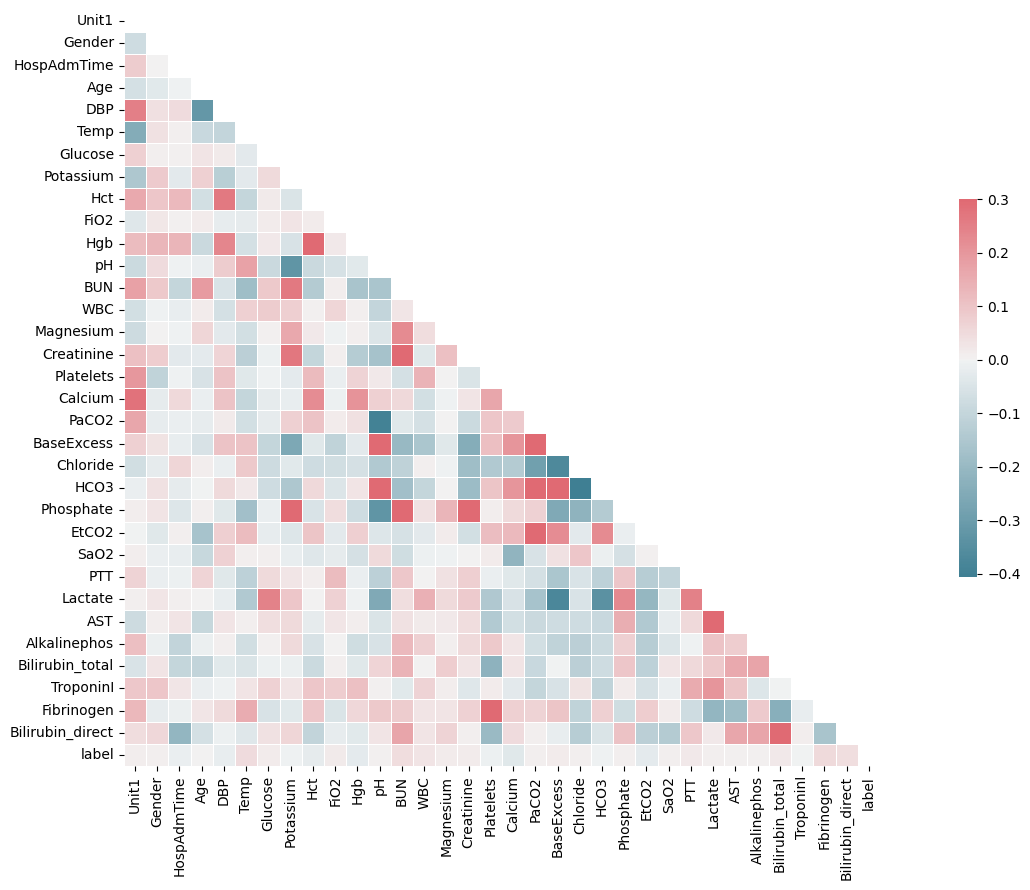

In [ ]:
# 移除 X_cont 欄位（陣列格式，無法計算相關係數）
train_corr = train.drop('X_cont', axis=1)
test_corr = test.drop('X_cont', axis=1)

# 計算特徵相關係數，只取下三角形避免重複
corr = train_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# 畫出相關性熱力圖並儲存
plt.figure(figsize=(16,9))
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.tight_layout()
plt.savefig('plots/heatmap.png', dpi=250)
plt.show()

# 無高度相關特徵，保留全部資料並儲存
train.to_pickle('train.pkl')
test.to_pickle('test.pkl')

經過分析，此資料集無高度相關特徵，保留全部特徵供模型訓練使用。

### 產出
- `plots/heatmap.png`：特徵相關性熱力圖
- `train.pkl`：最終訓練集
- `test.pkl`：最終測試集